## This notebook uses df_match_features.csv only. 
## Form, h2h, and FIFA rank are applied as adjustments in the simulation notebook, not as training features.

#
---

# SECTION 1:

## Data I have:

- Strength signals (Elo, FIFA rank) -> **df_match_features.csv**
- Form signal (recent goal differential, per team) -> **df_form_2026.csv**
- Pair-specific history (h2h with sample-size guard) -> **df_h2h_2026.csv**
- Match context (tournament weight, neutral venue, confederation) -> **df_match_features.csv**

# Model Goal

- Poisson goals model: predict λ_home and λ_away (expected goals for each side), then derive outcome probabilities by sampling.

In [1]:
import pandas as pd
df = pd.read_csv('../data/processed/df_match_features.csv', parse_dates=['date'])

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nDtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum()[df.isna().sum() > 0])

Shape: (49048, 16)

Columns:
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'home_elo_pre', 'away_elo_pre', 'elo_diff', 'tournament_weight', 'is_competitive', 'home_confederation', 'away_confederation']

Dtypes:
date                  datetime64[us]
home_team                        str
away_team                        str
home_score                   float64
away_score                   float64
tournament                       str
city                             str
country                          str
neutral                         bool
home_elo_pre                 float64
away_elo_pre                 float64
elo_diff                     float64
tournament_weight              int64
is_competitive                  bool
home_confederation               str
away_confederation               str
dtype: object

Missing values:
Series([], dtype: int64)


### What the model will actually use
Out of those 16 columns, here's what's what:

##### Identifiers (not features): date, home_team, away_team, city, country. These tell you which match it is, not anything predictive.

##### Targets: home_score, away_score. The things you're predicting. They can't be in the features.
##### Drop: tournament, is_competitive. tournament has too many unique values to one-hot encode sensibly (200+ tournaments). is_competitive is information you'll use to filter the training set, not as a feature.

Actual features to feed the model (7):

- home_elo_pre — home team strength
- away_elo_pre — away team strength
- elo_diff — useful for simpler models, redundant for tree models but harmless
- tournament_weight — match importance
- neutral — venue type (boolean)
- home_confederation — categorical (one-hot it)
- away_confederation — categorical (one-hot it)

That's a focused, principled feature set. Not 50 columns of noise.

In [2]:
print(df.shape)
df.head(2)

(49048, 16)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo_pre,away_elo_pre,elo_diff,tournament_weight,is_competitive,home_confederation,away_confederation
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1500.0000,1500.0000,0.0000,1,False,UEFA,UEFA
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1502.8013,1497.1987,5.6026,1,False,UEFA,UEFA


In [3]:
df['is_competitive'].value_counts()   

is_competitive
True     30796
False    18252
Name: count, dtype: int64

In [4]:
# Use only competitive matches for training (remove friendlies and the cold-start NaN rows)
train_df = df[df['is_competitive']].copy()
print(f"Training on {len(train_df):,} competitive matches")

Training on 30,796 competitive matches


### Why two separate Poisson models
This is worth understanding before you write code. Football models predict goals as two independent Poisson distributions:

- Model A: predict λ_home (expected goals scored by home team)
- Model B: predict λ_away (expected goals scored by away team)

Both models use the same features, just with the target swapped. Then you sample from each Poisson to get score lines, and outcomes derive from there.

#
----

# SECTION 2: Poisson Models

# Train test split

In [5]:
# Build the training set / Filter out before 2000
train_df = df[df['is_competitive'] & (df['date'] >= '2000-01-01')].copy()

train = train_df[train_df['date'] < '2024-01-01']
valid = train_df[train_df['date'] >= '2024-01-01']

print(f"Train: {len(train):,} matches ({train['date'].min().year}–{train['date'].max().year})")
print(f"Valid: {len(valid):,} matches ({valid['date'].min().year}–{valid['date'].max().year})")

Train: 14,820 matches (2000–2023)
Valid: 1,854 matches (2024–2026)


#### I picked 2000 to balance sample size against tactical era stability. Earlier would dilute the signal, later would limit data

# Fit 2 Poisson Models

In [6]:
import statsmodels.api as sm
import pandas as pd

# Define the feature columns
numeric_features = ['home_elo_pre', 'away_elo_pre', 'tournament_weight']
categorical_features = ['home_confederation', 'away_confederation']

def build_design_matrix(df):
    """Convert features into a numeric matrix the model can consume."""
    X = df[numeric_features].copy()
    # Neutral venue as a boolean → int
    X['neutral'] = df['neutral'].astype(int)
    # One-hot encode confederations (drop_first avoids the dummy-variable trap)
    cats = pd.get_dummies(df[categorical_features], drop_first=True).astype(int)
    X = pd.concat([X, cats], axis=1)
    # Add intercept column (required by statsmodels GLM)
    X = sm.add_constant(X, has_constant='add')
    return X

# Build design matrices
X_train = build_design_matrix(train)
X_valid = build_design_matrix(valid)

# Make sure validation has the same columns as train (handles any missing categories)
X_valid = X_valid.reindex(columns=X_train.columns, fill_value=0)

# Targets
y_home_train = train['home_score']
y_away_train = train['away_score']

# Fit Model A: expected home goals
model_home = sm.GLM(y_home_train, X_train, family=sm.families.Poisson()).fit()

# Fit Model B: expected away goals
model_away = sm.GLM(y_away_train, X_train, family=sm.families.Poisson()).fit()

print("=== Home goals model ===")
print(model_home.summary())
print("\n=== Away goals model ===")
print(model_away.summary())

=== Home goals model ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:             home_score   No. Observations:                14820
Model:                            GLM   Df Residuals:                    14803
Model Family:                 Poisson   Df Model:                           16
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -23792.
Date:                Mon, 01 Jun 2026   Deviance:                       19633.
Time:                        15:17:11   Pearson chi2:                 1.97e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3786
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

- That neutral: +0.37 for away goals is the cleanest validation that your model has correctly identified home advantage. 
- Without home support, the "away" team scores significantly more. That's a real, well-known effect in football.

### The single most important number to internalize
The two Elo coefficients (home and away) are your model's beating heart. They confirm:

- A team with 200 more Elo points than its opponent scores ~exp(0.0016×200) = 38% more goals while conceding ~exp(0.0021×200) = 52% fewer goals.
- For Argentina (Elo ~2180) vs Saudi Arabia (~1500): a 680-point gap → Argentina scores ~exp(0.0016×680) = 3x as many goals and concedes ~exp(0.0021×680) = ¼ as many. This is how the model knows Argentina should win most of those matchups.

#
-----

# Section 3 : Validation on holdout data (2024-2026)

## Check 1: Mean Absolute Error on goal predictions

In [7]:
# Predict expected goals for validation set
y_home_pred = model_home.predict(X_valid)
y_away_pred = model_away.predict(X_valid)

# Actual goals
y_home_actual = valid['home_score']
y_away_actual = valid['away_score']

# Mean absolute error
mae_home = (y_home_pred - y_home_actual).abs().mean()
mae_away = (y_away_pred - y_away_actual).abs().mean()

print(f"Home goals MAE: model predicts HOME goals off by {mae_home:.3f}")
print(f"Away goals MAE: model predicts AWAY goals off by {mae_away:.3f}")
print(f"Mean predicted home goals: {y_home_pred.mean():.2f} (actual: {y_home_actual.mean():.2f})")
print(f"Mean predicted away goals: {y_away_pred.mean():.2f} (actual: {y_away_actual.mean():.2f})")

Home goals MAE: model predicts HOME goals off by 1.054
Away goals MAE: model predicts AWAY goals off by 0.870
Mean predicted home goals: 1.72 (actual: 1.60)
Mean predicted away goals: 1.18 (actual: 1.17)


- My model overpredicts home goals by about 0.12 on average.
- It's small, but it tells me the model has slightly too much faith in home advantage. 
- For the World Cup, every match is neutral anyway — so home advantage doesn't apply, and this bias won't affect the simulation.

PS: The Poisson model is deterministic If you rerun model_home.predict(X_valid) ten times, you'll get exactly the same numbers every time. 

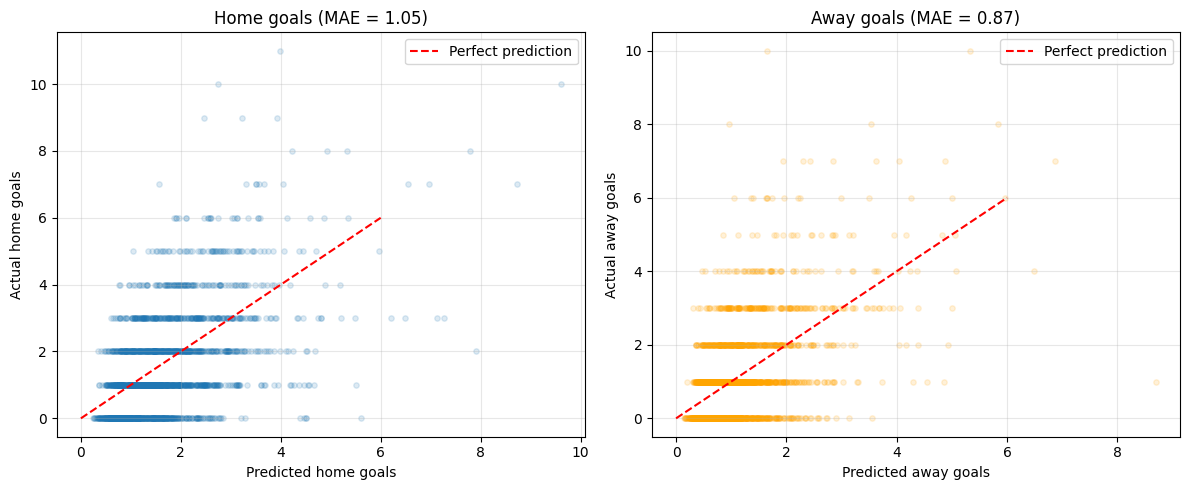

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Home goals
axes[0].scatter(y_home_pred, y_home_actual, alpha=0.15, s=15)
axes[0].plot([0, 6], [0, 6], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Predicted home goals')
axes[0].set_ylabel('Actual home goals')
axes[0].set_title(f'Home goals (MAE = {mae_home:.2f})')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Away goals
axes[1].scatter(y_away_pred, y_away_actual, alpha=0.15, s=15, color='orange')
axes[1].plot([0, 6], [0, 6], 'r--', label='Perfect prediction')
axes[1].set_xlabel('Predicted away goals')
axes[1].set_ylabel('Actual away goals')
axes[1].set_title(f'Away goals (MAE = {mae_away:.2f})')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

- The cloud of dots clusters around the red diagonal — meaning when the model predicts ~2 goals, actual goals come out around 2 on average. 
- The vertical spread is the irreducible noise of football: you can predict the average, but never the exact score.

## Check 2: Outcome accuracy (Monte Carlo Simulation)

In [8]:
import numpy as np

def predict_outcome(lambda_h, lambda_a, n_sims=10000):
    """Sample from both Poissons many times, return outcome probabilities."""
    home_goals = np.random.poisson(lambda_h, n_sims)
    away_goals = np.random.poisson(lambda_a, n_sims)
    p_home = (home_goals > away_goals).mean()
    p_draw = (home_goals == away_goals).mean()
    p_away = (home_goals < away_goals).mean()
    return p_home, p_draw, p_away

# Get predicted outcome for each validation match
valid = valid.reset_index(drop=True)
outcome_probs = [predict_outcome(h, a) for h, a in zip(y_home_pred, y_away_pred)]
valid['p_home'] = [o[0] for o in outcome_probs]
valid['p_draw'] = [o[1] for o in outcome_probs]
valid['p_away'] = [o[2] for o in outcome_probs]

# Predicted outcome = highest probability
valid['pred_outcome'] = valid[['p_home', 'p_draw', 'p_away']].idxmax(axis=1).str.replace('p_', '')

# Actual outcome
def actual_outcome(row):
    if row['home_score'] > row['away_score']: return 'home'
    if row['home_score'] < row['away_score']: return 'away'
    return 'draw'

valid['actual_outcome'] = valid.apply(actual_outcome, axis=1)

# Accuracy
accuracy = (valid['pred_outcome'] == valid['actual_outcome']).mean()
print(f"Outcome accuracy: {accuracy:.1%}")
print(f"\nConfusion:")
print(pd.crosstab(valid['actual_outcome'], valid['pred_outcome']))

Outcome accuracy: 60.5%

Confusion:
pred_outcome    away  home
actual_outcome            
away             372   186
draw             155   277
home             114   750


- Outcome accuracy: 60.5% — solid, in the range of credible football models (538, bookmakers' implied probabilities are typically 55-62%).
- That number answered: "How often was the highest-probability outcome the actual outcome?"
- The confusion matrix: the column for "draw" predictions is missing entirely because the model never picks draw as the most likely outcome (it's almost always the second-place option). All 432 actual draws got misclassified — 277 as home wins, 155 as away wins.
- For home the model gets 750 out of 1027 (73% GREAT)
- For Away the model gets 372 out of 641  (58% good)

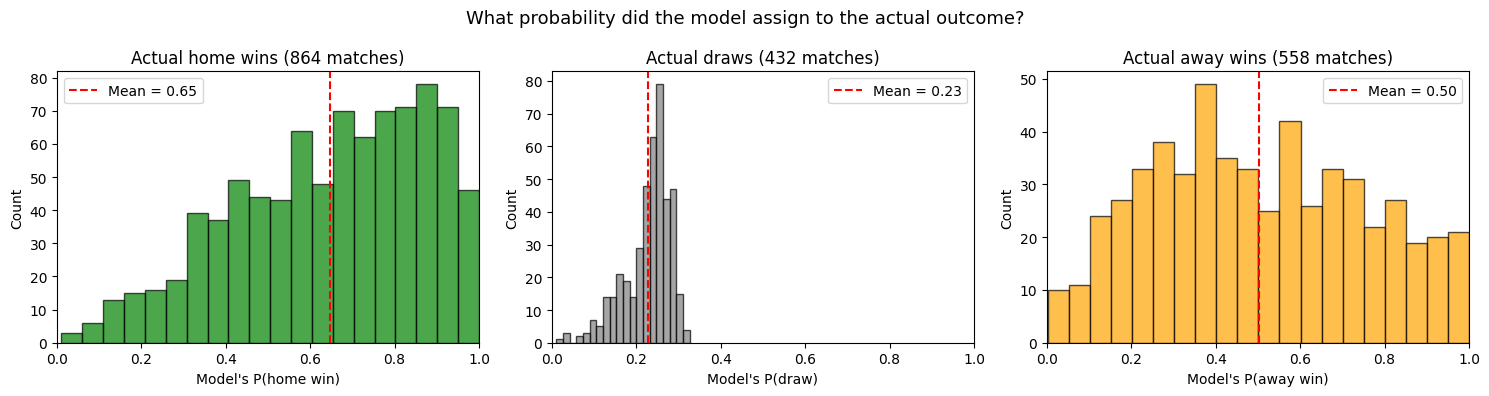

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Home wins: what P(home win) did the model assign?
home_wins = valid[valid['actual_outcome'] == 'home']['p_home']
axes[0].hist(home_wins, bins=20, color='green', alpha=0.7, edgecolor='black')
axes[0].axvline(home_wins.mean(), color='red', linestyle='--',
                label=f'Mean = {home_wins.mean():.2f}')
axes[0].set_title(f'Actual home wins ({len(home_wins)} matches)')
axes[0].set_xlabel('Model\'s P(home win)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].set_xlim(0, 1)

# Draws: what P(draw) did the model assign?
draws = valid[valid['actual_outcome'] == 'draw']['p_draw']
axes[1].hist(draws, bins=20, color='gray', alpha=0.7, edgecolor='black')
axes[1].axvline(draws.mean(), color='red', linestyle='--',
                label=f'Mean = {draws.mean():.2f}')
axes[1].set_title(f'Actual draws ({len(draws)} matches)')
axes[1].set_xlabel('Model\'s P(draw)')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].set_xlim(0, 1)

# Away wins
away_wins = valid[valid['actual_outcome'] == 'away']['p_away']
axes[2].hist(away_wins, bins=20, color='orange', alpha=0.7, edgecolor='black')
axes[2].axvline(away_wins.mean(), color='red', linestyle='--',
                label=f'Mean = {away_wins.mean():.2f}')
axes[2].set_title(f'Actual away wins ({len(away_wins)} matches)')
axes[2].set_xlabel('Model\'s P(away win)')
axes[2].set_ylabel('Count')
axes[2].legend()
axes[2].set_xlim(0, 1)

plt.suptitle('What probability did the model assign to the actual outcome?', fontsize=13)
plt.tight_layout()
plt.show()

The chart answers a different question: "When a specific outcome actually happened, what probability did the model assign to it?"
The three means come from three different subsets of matches:

- 0.65 — restricted to the 864 matches where home actually won. Across those matches, the model assigned an average P(home win) of 0.65.
- 0.23 — restricted to the 432 matches where a draw actually happened. Across those, the model's average P(draw) was 0.23.
- 0.50 — restricted to the 558 matches where away actually won. Across those, the model's average P(away win) was 0.50.

#### the chart means are more useful for the project.

## Check 3 - Calibration plot

   p_home_bin  predicted    actual    n
0  (0.0, 0.1]   0.048416  0.048611  144
1  (0.1, 0.2]   0.151434  0.142132  197
2  (0.2, 0.3]   0.251925  0.189349  169
3  (0.3, 0.4]   0.350027  0.350000  220
4  (0.4, 0.5]   0.449893  0.421296  216
5  (0.5, 0.6]   0.553145  0.502283  219
6  (0.6, 0.7]   0.651387  0.617801  191
7  (0.7, 0.8]   0.750846  0.700000  190
8  (0.8, 0.9]   0.850823  0.824176  182
9  (0.9, 1.0]   0.944902  0.936508  126


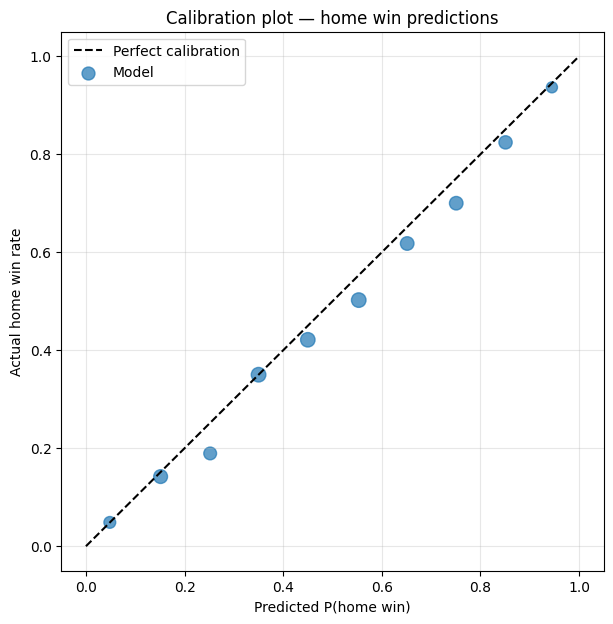

In [11]:
import matplotlib.pyplot as plt

# Bin predictions by their probability
bins = np.linspace(0, 1, 11)  # 0-10%, 10-20%, ..., 90-100%
valid['p_home_bin'] = pd.cut(valid['p_home'], bins=bins)

# For each bin, compute actual home win rate
calibration = valid.groupby('p_home_bin', observed=True).agg(
    predicted=('p_home', 'mean'),
    actual=('actual_outcome', lambda x: (x == 'home').mean()),
    n=('p_home', 'size')
).reset_index()

print(calibration)

# Plot
plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.scatter(calibration['predicted'], calibration['actual'],
            s=calibration['n']*0.5, alpha=0.7, label='Model')
plt.xlabel('Predicted P(home win)')
plt.ylabel('Actual home win rate')
plt.title('Calibration plot — home win predictions')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

- This is genuinely good calibration. Every dot is within ~5 percentage points of the diagonal.

# 
----

# SAVE Models 

In [13]:
import pickle

# The two trained Poisson models
with open('../models/poisson_home.pkl', 'wb') as f:
    pickle.dump(model_home, f)

with open('../models/poisson_away.pkl', 'wb') as f:
    pickle.dump(model_away, f)

# The column order of your design matrix — silently important
with open('../models/feature_columns.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)

print("Saved 3 files to data/processed/")

Saved 3 files to data/processed/
